## Python Notebook 3: Regression DT & Ensemble Learners

Author: Santosh Manoharadas  
Student ID: w1954095 / 20220967  
Module: 5DATA002W.2 Machine Learning and Data Mining


## Section 1 - Import Libraries
Importing Ensemble and Regression Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeRegressor, export_graphviz, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import graphviz
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## PART A - Voting Ensemble Classifier (Task 5f - Case Study A)

## Section 2 - Load Classification Dataset and Rebuild Base Learners
Loading Data and Rebuilding Base Learners**

In [ ]:
df_cls = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML CWK/loan_classification_clean.csv')

X = df_cls.drop(columns=['loan_approval_status'])
y = df_cls['loan_approval_status']

# Split data using the same settings as Notebook 2 for consistency
# random_state=42 and stratify=y ensure same split and class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Apply StandardScaler - fit on training data only, transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")

Training set: (41051, 10), Test set: (17594, 10)


In [ ]:
# Define classification evaluation helper function
def evaluate_classifier(model, X_test, y_test, model_name, color='darkorange'):
    # Generate predictions
    y_pred = model.predict(X_test)
    # Generate predicted probabilities for ROC AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute metrics
    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred, pos_label=0)
    prec = precision_score(y_test, y_pred, pos_label=0)
    f1   = f1_score(y_test, y_pred, pos_label=0)
    auc  = roc_auc_score(y_test, y_prob)

    # Print metrics
    print(f"\n{'='*50}\n Model: {model_name}\n{'='*50}")
    print(f" Accuracy: {acc:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f} | F1: {f1:.4f} | AUC-ROC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

    # Plot confusion matrix and ROC curve
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Rejected (0)', 'Approved (1)']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'{model_name} - Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name} - AUC-ROC Curve')
    axes[1].legend(loc='lower right')
    plt.suptitle(f'Evaluation - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Recall': rec,
            'Precision': prec, 'F1-Score': f1, 'AUC-ROC': auc}

print("Helper function defined.")

Helper function defined.


---
## Section 3 - Build and Evaluate the Two Chosen Base Learners
Declaring, Fitting and Evaluating TWO Base Learners



 Model: Base Learner 1: LR
 Accuracy: 0.8927 | Recall: 0.9761 | Precision: 0.9061 | F1: 0.9398 | AUC-ROC: 0.8751

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.91      0.98      0.94     15089
Approved (1)       0.73      0.39      0.51      2505

    accuracy                           0.89     17594
   macro avg       0.82      0.68      0.72     17594
weighted avg       0.88      0.89      0.88     17594



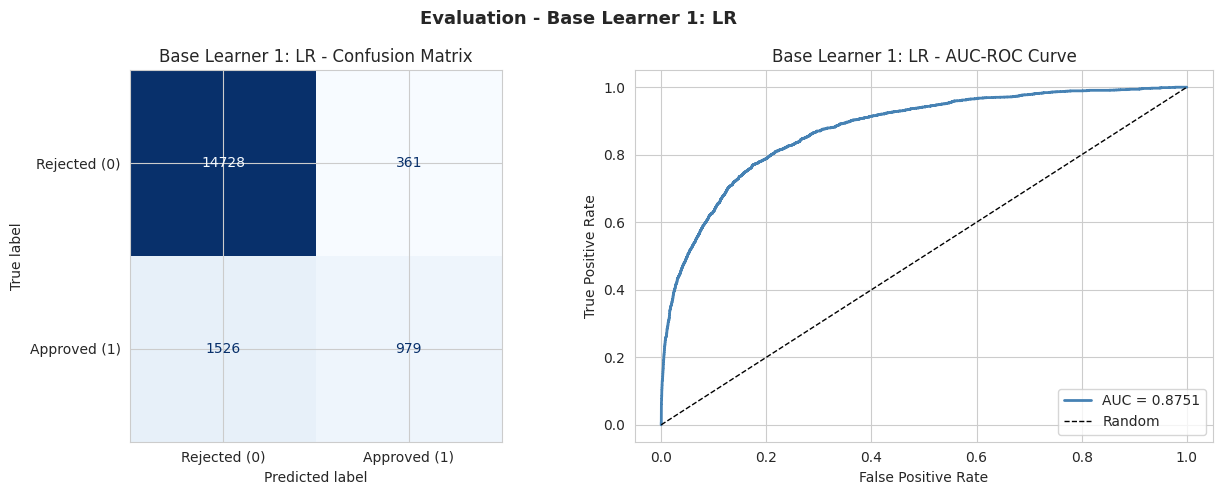

In [ ]:
base_lr = LogisticRegression(max_iter=1000, random_state=42, C=1, penalty='l2', solver='liblinear')
base_lr.fit(X_train_scaled, y_train)
bl1_results = evaluate_classifier(base_lr, X_test_scaled, y_test, 'Base Learner 1: LR', color='steelblue')


 Model: Base Learner 2: NB
 Accuracy: 0.8494 | Recall: 0.8898 | Precision: 0.9316 | F1: 0.9102 | AUC-ROC: 0.8594

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.93      0.89      0.91     15089
Approved (1)       0.48      0.61      0.53      2505

    accuracy                           0.85     17594
   macro avg       0.70      0.75      0.72     17594
weighted avg       0.87      0.85      0.86     17594



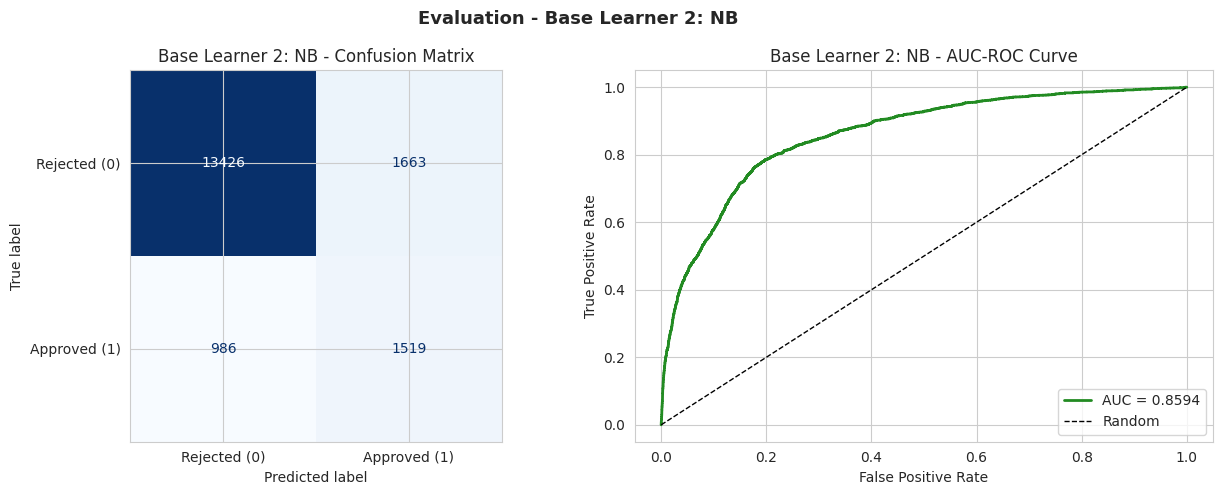

In [ ]:
base_nb = GaussianNB()
base_nb.fit(X_train_scaled, y_train)
bl2_results = evaluate_classifier(base_nb, X_test_scaled, y_test, 'Base Learner 2: NB', color='forestgreen')

---
## Section 4 - Build and Evaluate the Voting Ensemble Classifier
Importing, Declaring, Fitting and Evaluating the Ensemble Learner**


 Model: Voting Ensemble (LR + NB)
 Accuracy: 0.8806 | Recall: 0.9352 | Precision: 0.9263 | F1: 0.9307 | AUC-ROC: 0.8730

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.93      0.94      0.93     15089
Approved (1)       0.59      0.55      0.57      2505

    accuracy                           0.88     17594
   macro avg       0.76      0.74      0.75     17594
weighted avg       0.88      0.88      0.88     17594



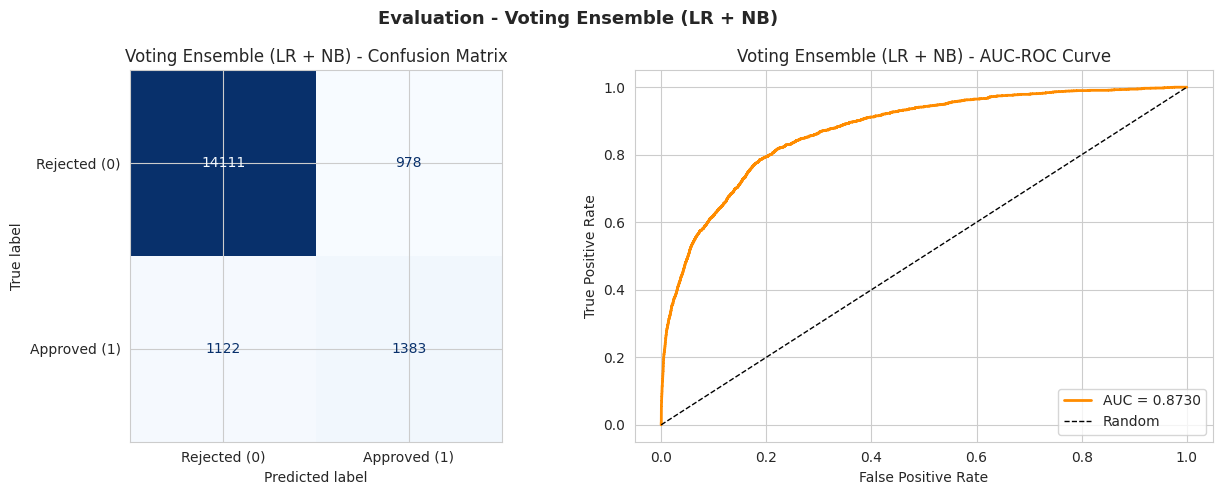

In [ ]:
# Declare the probability-based (soft) voting ensemble classifier
# voting='soft' uses predicted probabilities (not hard votes) for better performance
# Combines Base Learner 1 (LR) and Base Learner 2 (NB)
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42, C=1, penalty='l2', solver='liblinear')),
        ('nb', GaussianNB())
    ],
    voting='soft'
)

ensemble_model.fit(X_train_scaled, y_train)
ensemble_results = evaluate_classifier(
    ensemble_model, X_test_scaled, y_test, 'Voting Ensemble (LR + NB)', color='darkorange'
)

In [ ]:
ensemble_comparison = pd.DataFrame([bl1_results, bl2_results, ensemble_results]).set_index('Model').round(4)
print("\n=== Ensemble vs Base Learners Comparison ===")
print(ensemble_comparison.to_string())


=== Ensemble vs Base Learners Comparison ===
                           Accuracy  Recall  Precision  F1-Score  AUC-ROC
Model                                                                    
Base Learner 1: LR           0.8927  0.9761     0.9061    0.9398   0.8751
Base Learner 2: NB           0.8494  0.8898     0.9316    0.9102   0.8594
Voting Ensemble (LR + NB)    0.8806  0.9352     0.9263    0.9307   0.8730


---
## PART B - Regression Decision Trees (Case Study B)

---
## Section 5 - Load Regression Dataset
Loading the Regression Dataset**

In [ ]:
df_reg = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML CWK/loan_regression_clean.csv')
X_reg = df_reg.drop(columns=['max_allowed_loan', 'loan_approval_status'])
y_reg = df_reg['max_allowed_loan']
print("Regression Input Features:")
print(X_reg.columns.tolist())
print(f"\nFeature matrix shape: {X_reg.shape}")
print(f"Target shape: {y_reg.shape}")

Regression Input Features:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Feature matrix shape: (50292, 10)
Target shape: (50292,)


---
## Section 6 - Regression Train-Test Split
Train-Test Split for Regression**

In [ ]:
# Split the regression dataset into 70% training and 30% test
# random_state=42 ensures reproducibility for both DT models
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)
print(f"Regression Training set: {X_reg_train.shape}")
print(f"Regression Test set: {X_reg_test.shape}")

Regression Training set: (35204, 10)
Regression Test set: (15088, 10)


---
## Section 7 - Build DT-1: Fully Grown Decision Tree Regressor
Importing, Declaring and Fitting the Fully Grown DT Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Declare DT-1: Fully Grown Decision Tree Regressor (no depth constraint)
# No max_depth - tree grows until all leaves are pure or contain min_samples_split records
dt1 = DecisionTreeRegressor(random_state=42)
dt1.fit(X_reg_train, y_reg_train)

print(f"DT-1 (Fully Grown) - Tree Depth: {dt1.get_depth()}")
print(f"DT-1 - Number of Leaves: {dt1.get_n_leaves()}")

DT-1 (Fully Grown) - Tree Depth: 24
DT-1 - Number of Leaves: 20744


---
## Section 8 - Build DT-2: Pruned Decision Tree Regressor (max_depth=4)
Importing, Declaring and Fitting the Pruned DT Regressor**

Pre-pruning via `max_depth=4` is applied. This is **pre-pruning** - limiting tree growth before it overfits. This approach reduces model variance (overfitting) and makes the tree more interpretable, but may increase bias (underfitting) compared to DT-1.

In [ ]:
# Declare DT-2: Pruned Decision Tree Regressor constrained to max 4 levels depth
# max_depth=4 implements pre-pruning (top-down constraint on tree growth)
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)
dt2.fit(X_reg_train, y_reg_train)

print(f"DT-2 (Pruned max_depth=4) - Tree Depth: {dt2.get_depth()}")
print(f"DT-2 - Number of Leaves: {dt2.get_n_leaves()}")

DT-2 (Pruned max_depth=4) - Tree Depth: 4
DT-2 - Number of Leaves: 16


---
## Section 9 - Visualise Decision Trees (Task 2c - Case Study B)
Visualising Decision Trees with plot_tree**

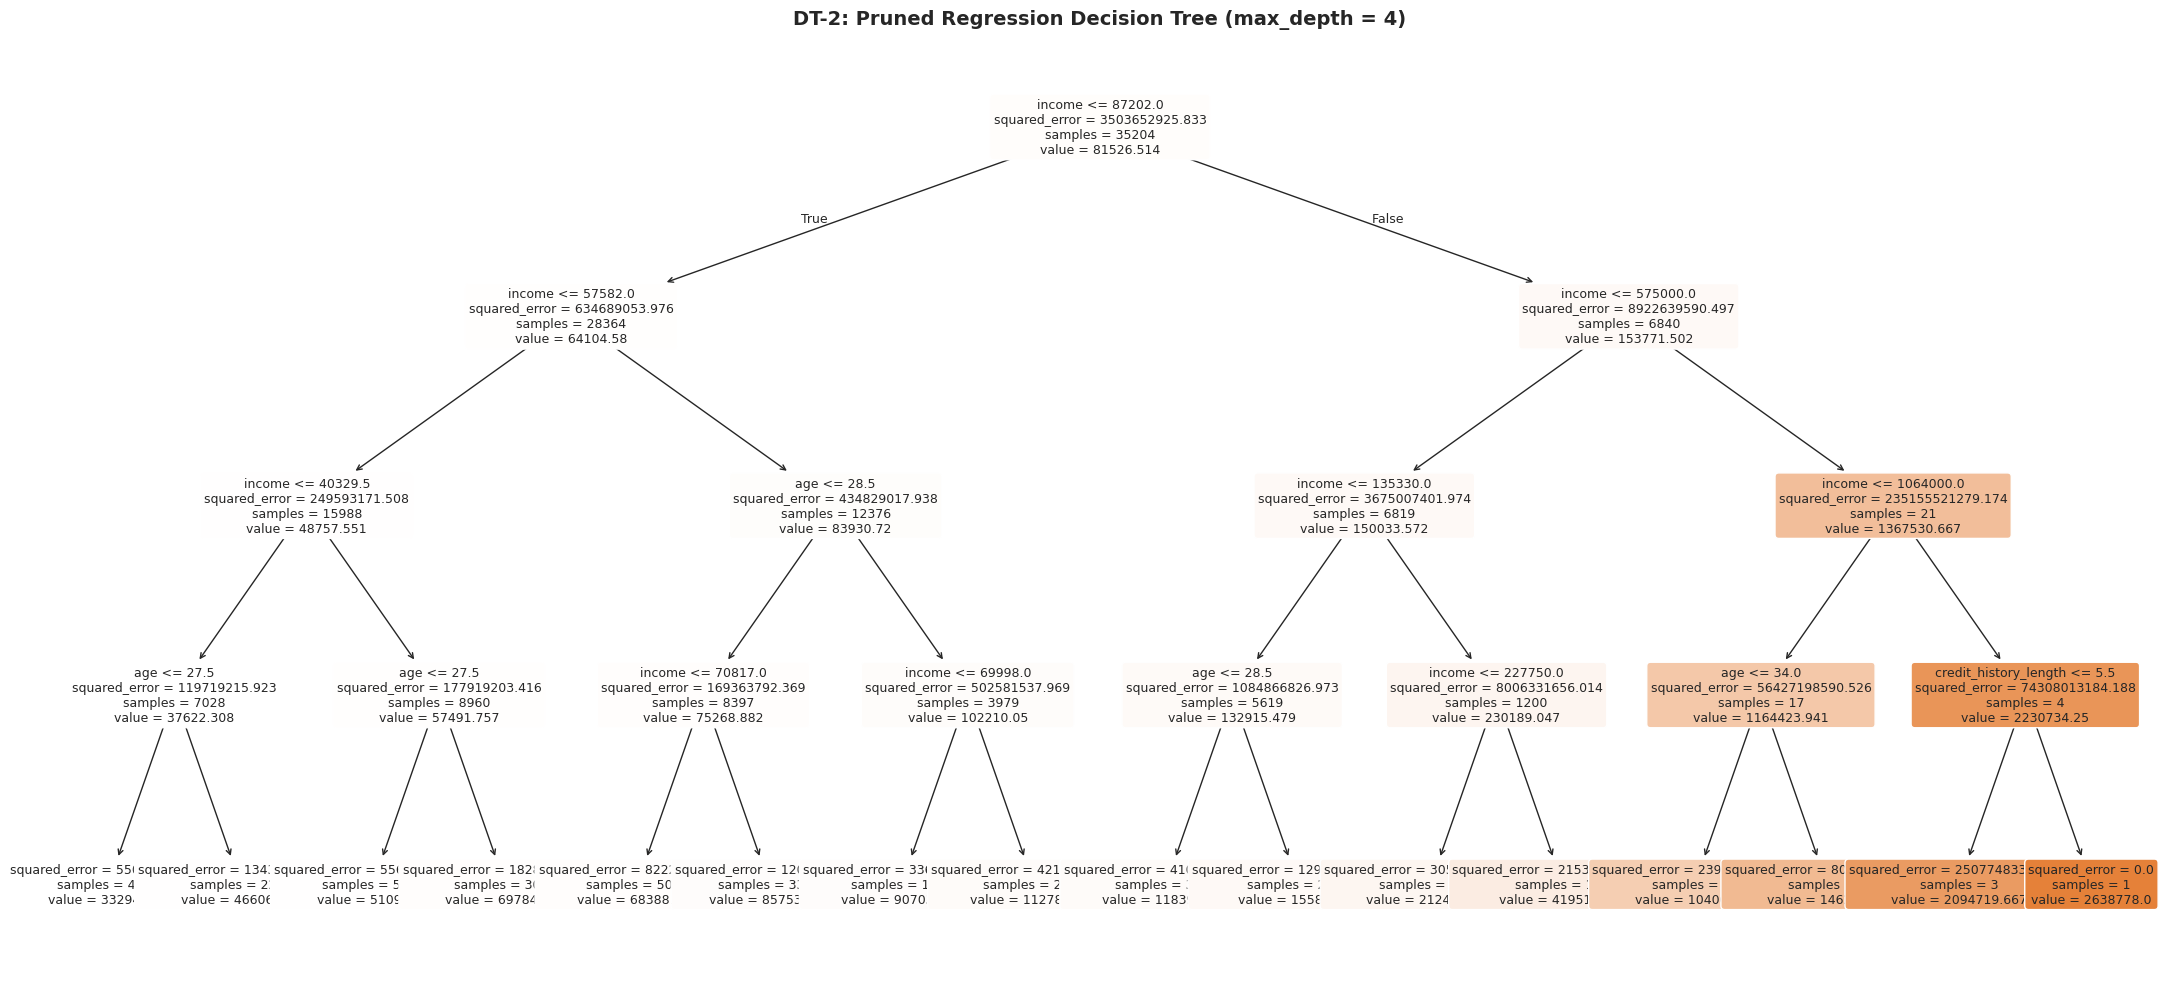

DT-2 tree saved as: DT2_pruned_tree.png


In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(22, 10))
plot_tree(
    dt2,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4
)
plt.title('DT-2: Pruned Regression Decision Tree (max_depth = 4)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('DT2_pruned_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("DT-2 tree saved as: DT2_pruned_tree.png")

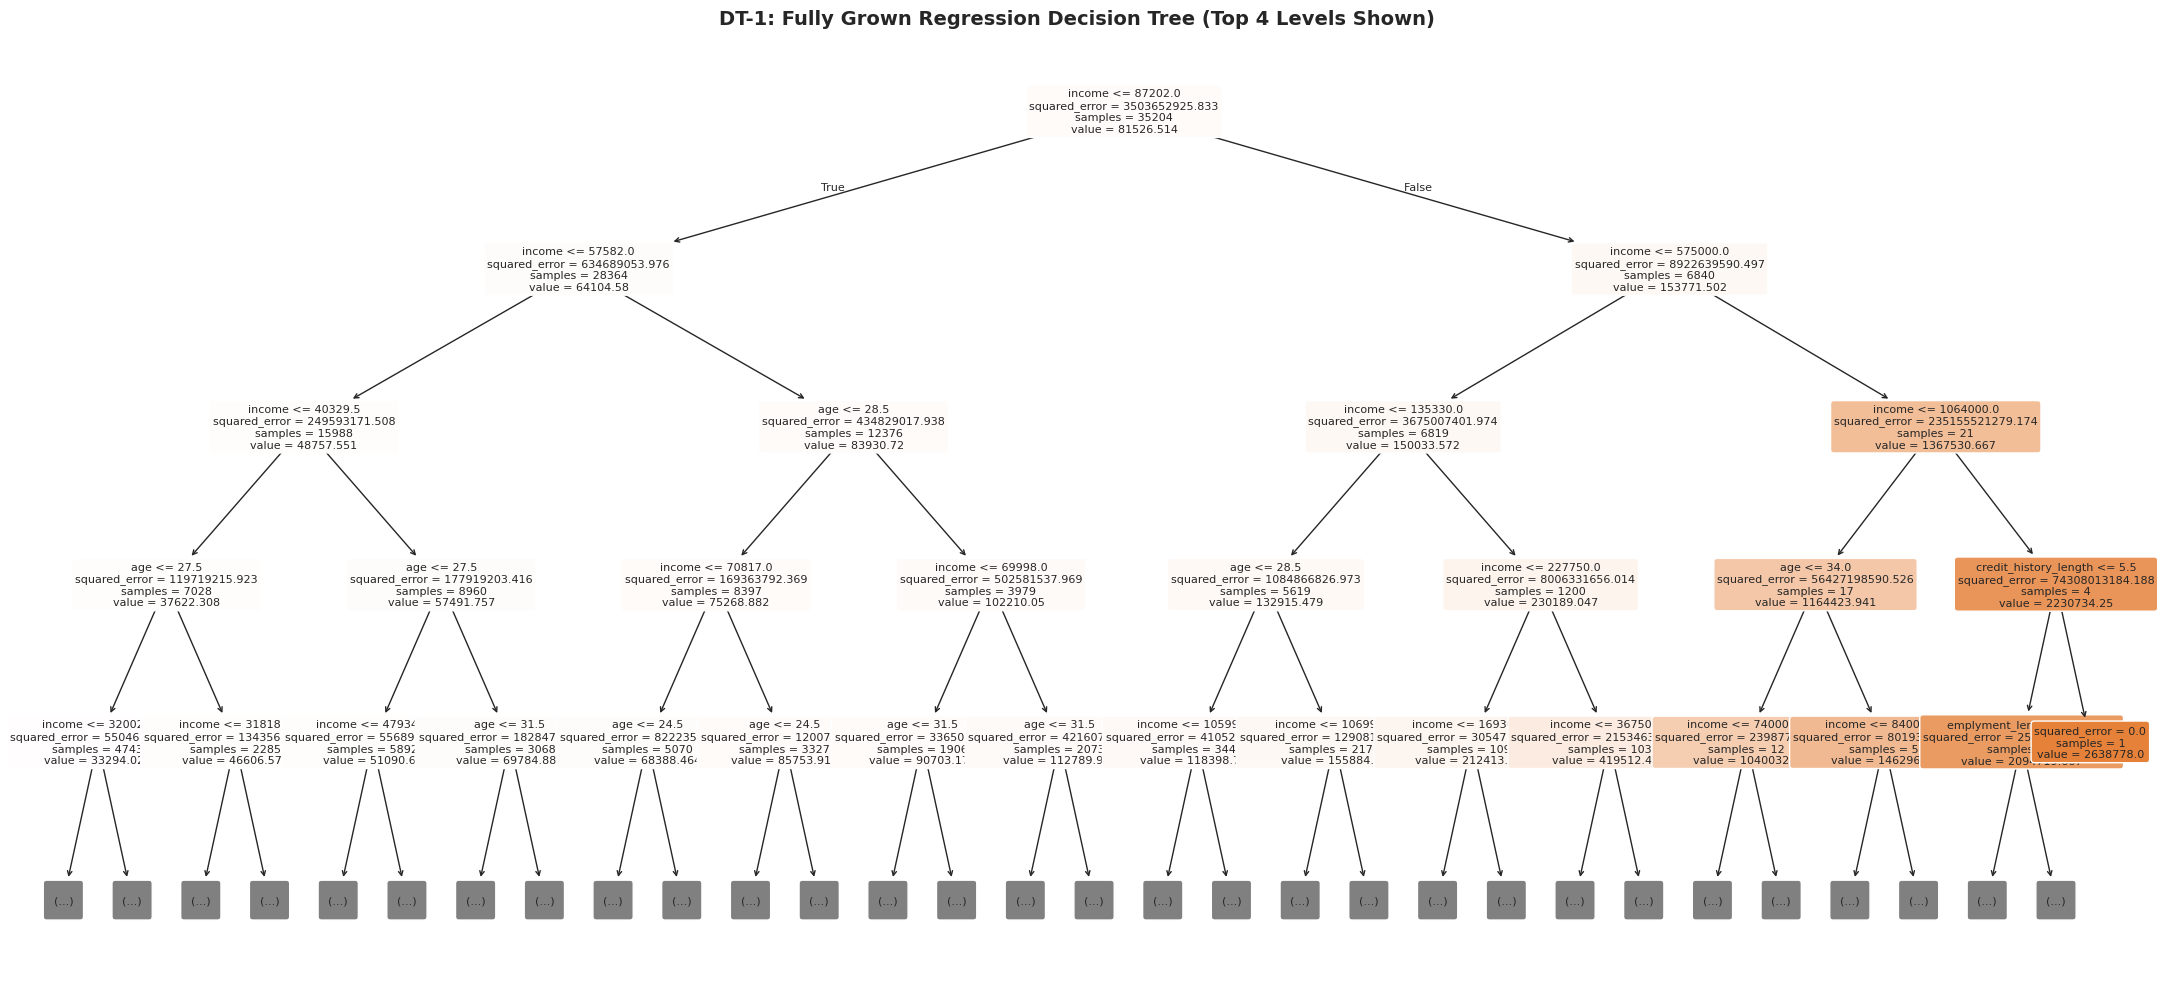

DT-1 top-4-level tree saved as: DT1_fullgrown_tree.png


In [ ]:
# Full tree is too large to display; top 4 levels shown for structure insight
plt.figure(figsize=(22, 10))
plot_tree(
    dt1,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4  # Showing top 4 levels of the fully grown tree for legibility
)
plt.title('DT-1: Fully Grown Regression Decision Tree (Top 4 Levels Shown)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('DT1_fullgrown_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("DT-1 top-4-level tree saved as: DT1_fullgrown_tree.png")

## Section 10 - Evaluate Regression Models (Task 3a - Case Study B)
Evaluating DT Regressors with MSE, MAE, R²**

In [ ]:
def evaluate_regressor(model, X_test, y_test, model_name):
    """
    Evaluates a fitted regressor on the test set.
    Computes MSE, MAE and R-squared, and plots actual vs predicted values.
    """
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f" Model: {model_name}")
    print(f"{'='*50}")
    print(f" MSE      : {mse:,.2f}")
    print(f" RMSE     : {np.sqrt(mse):,.2f}")
    print(f" MAE      : {mae:,.2f}")
    print(f" R-Squared: {r2:.4f}")
    print(f"{'='*50}")


    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.2, color='steelblue', s=10)
    # Plot the ideal prediction line (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
    plt.xlabel('Actual Max Loan Amount (£)', fontsize=11)
    plt.ylabel('Predicted Max Loan Amount (£)', fontsize=11)
    plt.title(f'{model_name} - Actual vs Predicted', fontsize=12, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'MSE': round(mse, 2), 'MAE': round(mae, 2), 'R²': round(r2, 4)}

print("Regression evaluation function defined.")

Regression evaluation function defined.



 Model: DT-1: Fully Grown
 MSE      : 125,939,276.83
 RMSE     : 11,222.27
 MAE      : 1,435.40
 R-Squared: 0.9592


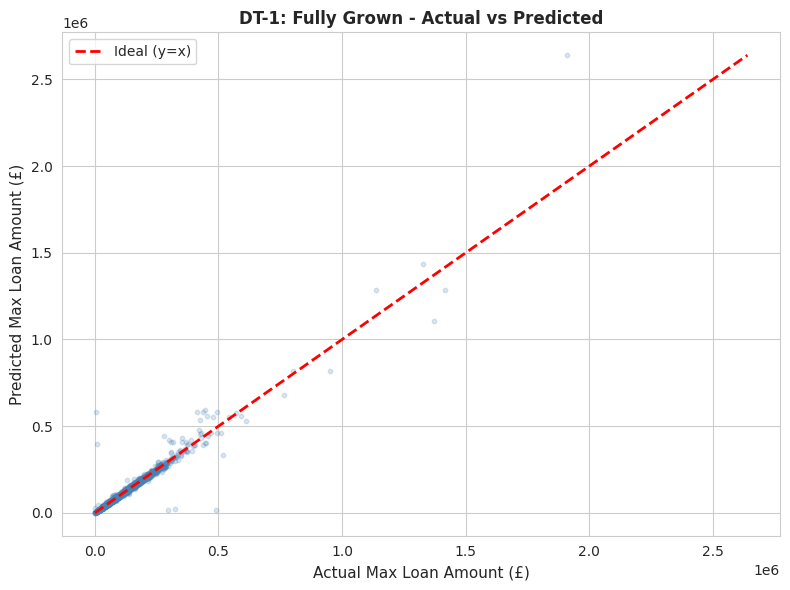

In [ ]:
dt1_results = evaluate_regressor(dt1, X_reg_test, y_reg_test, 'DT-1: Fully Grown')


 Model: DT-2: Pruned (max_depth=4)
 MSE      : 456,252,684.20
 RMSE     : 21,360.07
 MAE      : 11,645.95
 R-Squared: 0.8521


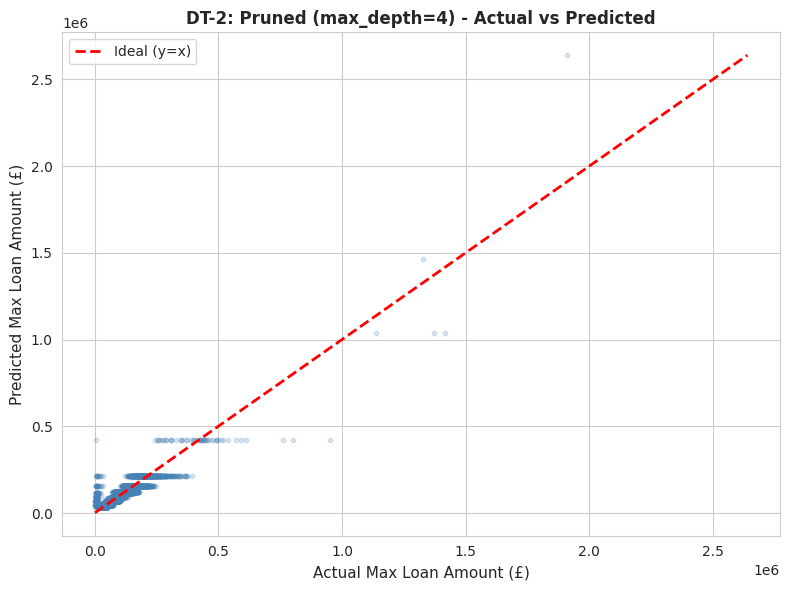

In [ ]:
dt2_results = evaluate_regressor(dt2, X_reg_test, y_reg_test, 'DT-2: Pruned (max_depth=4)')

In [ ]:
reg_comparison = pd.DataFrame([dt1_results, dt2_results]).set_index('Model')
print("\n=== Regression Model Comparison ===")
print(reg_comparison.to_string())


=== Regression Model Comparison ===
                                     MSE       MAE      R²
Model                                                     
DT-1: Fully Grown           1.259393e+08   1435.40  0.9592
DT-2: Pruned (max_depth=4)  4.562527e+08  11645.95  0.8521


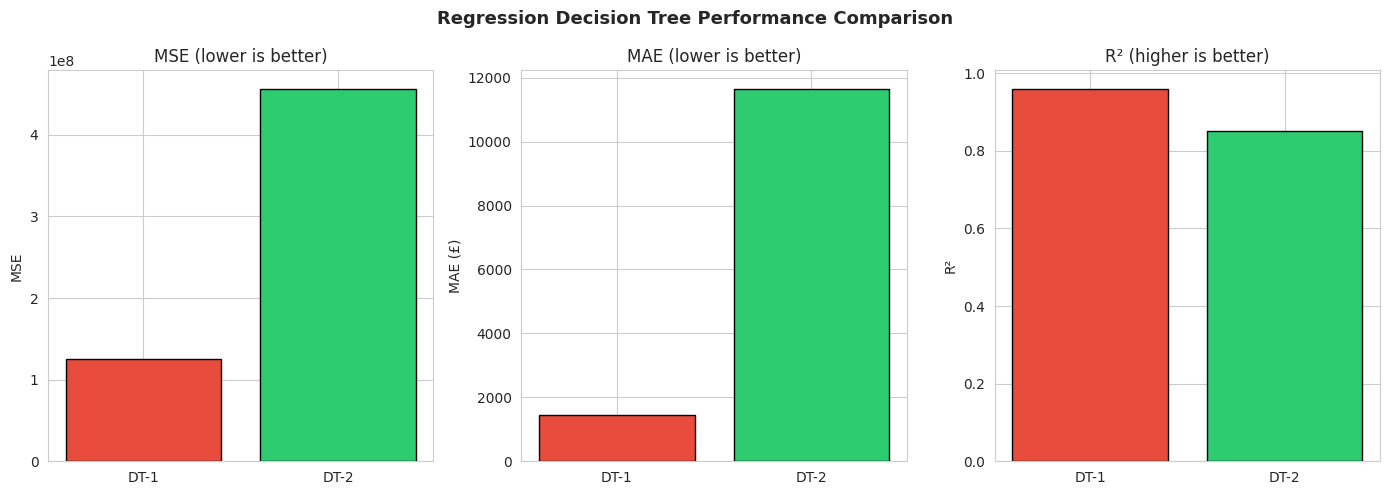

In [ ]:
# Visualise regression metric comparison (MAE and R²)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models = [r['Model'].split(':')[0] for r in [dt1_results, dt2_results]]

axes[0].bar(models, [dt1_results['MSE'], dt2_results['MSE']],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('MSE (lower is better)')
axes[0].set_ylabel('MSE')

axes[1].bar(models, [dt1_results['MAE'], dt2_results['MAE']],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('MAE (lower is better)')
axes[1].set_ylabel('MAE (£)')

axes[2].bar(models, [dt1_results['R²'], dt2_results['R²']],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title('R² (higher is better)')
axes[2].set_ylabel('R²')

plt.suptitle('Regression Decision Tree Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 11 - Predict Maximum Loan Amount for Client 60256 (Task 3d - Case Study B)
Using the Best DT Model for Single-Client Prediction

In [ ]:
# All values are encoded to match the format of the training data
# home_ownership: RENT, loan_intent: MEDICAL, payment_default_on_file: N

# Encode categorical values using the same mapping as Notebook 1
# home_ownership categories: MORTGAGE=0, OTHER=1, OWN=2, RENT=3
# loan_intent categories: DEBTCONSOLIDATION=0, EDUCATION=1, HOMEIMPROVEMENT=2,
#                         MEDICAL=3, PERSONAL=4, VENTURE=5
# payment_default_on_file: N=0, Y=1

client_60256 = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'home_ownership': 3,          # RENT encoded as 3
    'emplyment_length': 15,
    'loan_intent': 3,             # MEDICAL encoded as 3
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,    # 10% as decimal
    'payment_default_on_file': 0, # N = 0
    'credit_history_length': 35
}])

print("Client 60256 Feature Vector:")
print(client_60256.to_string())
print(f"\nFeature order check: {client_60256.columns.tolist() == X_reg.columns.tolist()}")

Client 60256 Feature Vector:
   age  income  home_ownership  emplyment_length  loan_intent  loan_amount  loan_interest_rate  loan_income_ratio  payment_default_on_file  credit_history_length
0   56   57000               3                15            3        25700                23.0                0.1                        0                     35

Feature order check: True


In [ ]:
# Select the best Decision Tree model based on MAE (lower is better)
best_model = dt1 if dt1_results['MAE'] < dt2_results['MAE'] else dt2

# Predict the maximum loan amount for Client 60256 using the selected best model
predicted_max_loan = best_model.predict(client_60256)[0]

# Identify which model was selected for reporting
model_name = "DT-1 (Fully Grown)" if best_model == dt1 else "DT-2 (Pruned, max_depth=4)"

# Display prediction result and model used
print(f"Predicted Maximum Loan Amount for Client 60256: £{predicted_max_loan:,.2f}")
print(f"\nModel used: {model_name}")

Predicted Maximum Loan Amount for Client 60256: £83,701.00

Model used: DT-1 (Fully Grown)


In [ ]:
# Trace the prediction path through the selected best model
# sklearn's decision_path returns the nodes each sample passes through
decision_path = best_model.decision_path(client_60256)

# Convert the sparse path output into a simple array
node_indicator = decision_path.toarray()[0]

# Get the list of visited node indices
visited_nodes = np.where(node_indicator)[0]

# Get the feature names in the same order used by the model
feature_names = X_reg.columns.tolist()

# Access the internal tree structure of the selected best model
tree = best_model.tree_

# Print a heading showing which model was used
print(f"Decision path for Client 60256 through {model_name} ({len(visited_nodes)} nodes):")
print("-" * 60)

# Trace each node in the decision path and print the split condition
for node_id in visited_nodes:
    # Check if this is a leaf node
    if tree.children_left[node_id] == tree.children_right[node_id]:
        print(f"  -> Leaf Node {node_id}: Predicted Value = £{tree.value[node_id][0][0]:,.2f}")
    else:
        # Get the split feature used at this node
        feature = feature_names[tree.feature[node_id]]

        # Get the threshold value used for the split
        threshold = tree.threshold[node_id]

        # Get the client's value for the feature
        client_value = client_60256[feature].values[0]

        # Decide whether the path went left or right
        direction = 'LEFT (<=)' if client_value <= threshold else 'RIGHT (>)'

        # Print the decision made at this node
        print(f"  Node {node_id}: {feature} = {client_value} | Threshold = {threshold:.4f} -> {direction}")

# Print the final prediction again for clarity
print(f"\nFinal Prediction: £{predicted_max_loan:,.2f}")

Decision path for Client 60256 through DT-1 (Fully Grown) (15 nodes):
------------------------------------------------------------
  Node 0: income = 57000 | Threshold = 87202.0000 -> LEFT (<=)
  Node 1: income = 57000 | Threshold = 57582.0000 -> LEFT (<=)
  Node 2: income = 57000 | Threshold = 40329.5000 -> RIGHT (>)
  Node 8740: age = 56 | Threshold = 27.5000 -> RIGHT (>)
  Node 14562: age = 56 | Threshold = 31.5000 -> RIGHT (>)
  Node 16476: income = 57000 | Threshold = 50002.0000 -> RIGHT (>)
  Node 18016: loan_income_ratio = 0.1 | Threshold = 0.2150 -> LEFT (<=)
  Node 18017: age = 56 | Threshold = 39.5000 -> RIGHT (>)
  Node 18497: age = 56 | Threshold = 40.5000 -> RIGHT (>)
  Node 18511: age = 56 | Threshold = 50.5000 -> RIGHT (>)
  Node 18671: age = 56 | Threshold = 60.5000 -> LEFT (<=)
  Node 18672: age = 56 | Threshold = 55.5000 -> RIGHT (>)
  Node 18688: loan_amount = 25700 | Threshold = 3400.0000 -> RIGHT (>)
  Node 18690: age = 56 | Threshold = 56.5000 -> LEFT (<=)
  -> Le


## Section 12 - Feature Importance (Regression)
Visualising Feature Importances from DT Models**

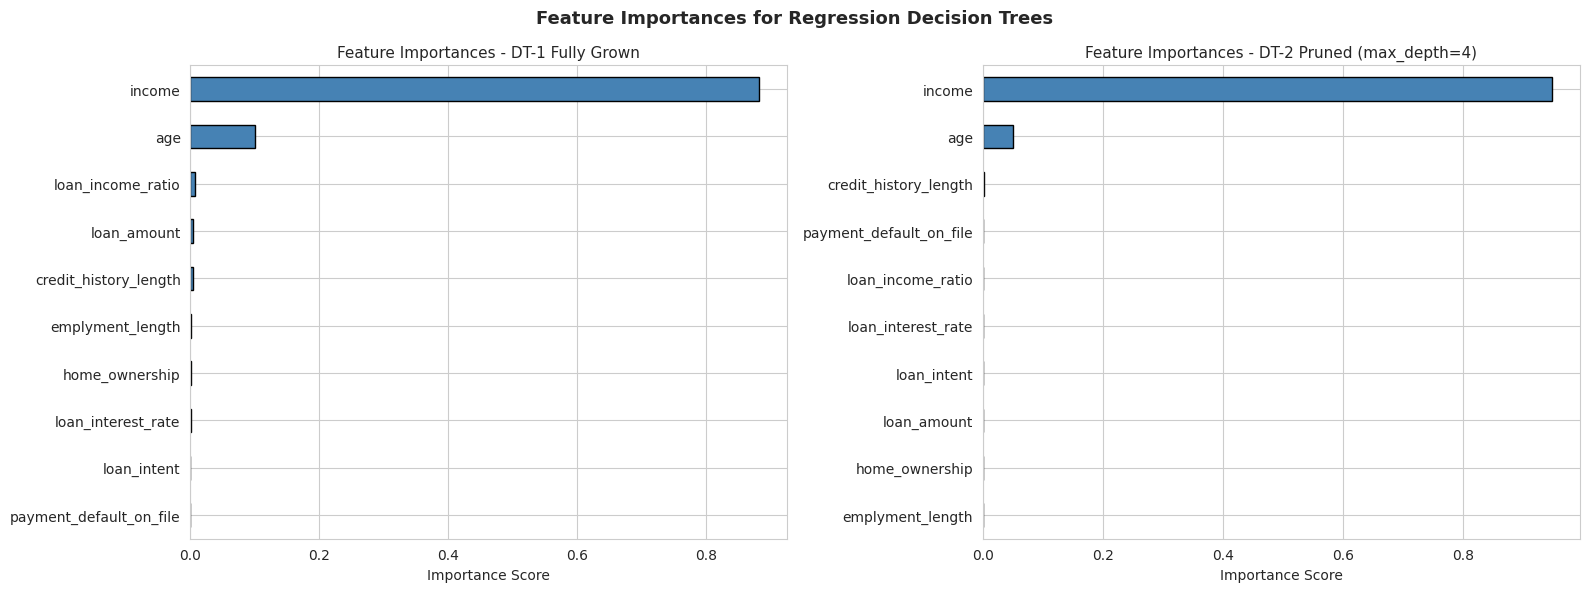

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, title in zip(axes, [dt1, dt2], ['DT-1 Fully Grown', 'DT-2 Pruned (max_depth=4)']):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X_reg.columns).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Feature Importances - {title}', fontsize=11)
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importances for Regression Decision Trees', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 13 - Final Summary

### Ensemble Results
The voting ensemble (LR + NB) combines the probabilistic outputs of both base learners. Refer to Section 4 output for the final comparison.

### Regression Results
Refer to Section 10 output for DT-1 vs DT-2 comparison. The best model for predicting Maximum Loan Amount is selected based on MAE (robust to extreme values, aligned with success criteria).

### Client 60256 Prediction
The predicted Maximum Loan Amount for Client 60256 is shown in Section 11.

### References
- Breiman, L. et al. (1984) *Classification and Regression Trees*. Chapman & Hall/CRC.
- Géron, A. (2019) *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 2nd edn. O'Reilly Media.
- Quinlan, J.R. (1993) *C4.5: Programs for Machine Learning*. Morgan Kaufmann.